> **Course notebook 4 of 5** | [Course home](../README.md) | [Previous: Token Embeddings](03_token_embeddings_demo.ipynb) | [Next: Complete Pipeline](05_llm_data_preprocessing_complete_pipeline.ipynb)
>
> **Prerequisite:** understand embedding lookup from Notebook 3; all new position and broadcasting terms are defined below. **Milestone:** combine token identity with sequence location and prove both learned tables receive gradients.

# Positional Embeddings — See Them, Add Them, Train Them

This notebook continues from token embeddings. We will focus on one new question:

> A token embedding tells us **what** a token is. How does the model also know **where** it occurs?

We will use small PyTorch examples, inspect actual numbers, visualize relative and sinusoidal positions, and finish with the realistic shape <code>8 × 4 × 256</code>. We will **not** build a Transformer.

## Start here: how does a model know token order?

A token embedding describes which token appears, but the same token receives the same initial vector wherever it occurs. Language also depends on order, so the model needs position information.

A learned positional embedding is a second lookup table. Token IDs select rows from a table shaped `[V, D]`; position numbers `0, 1, …, T-1` select rows from a table shaped `[T, D]`. Because both results end in dimension `D`, they can be added:

```text
input embedding = token embedding + positional embedding
```

For a batch, token embeddings have shape `[B, T, D]`. Position embeddings have shape `[T, D]` and are reused across the batch through broadcasting. This notebook makes those shapes visible, compares absolute and relative position ideas, and shows that learned position rows receive gradients.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(7)
torch.set_printoptions(precision=4, sci_mode=False)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.9.1+cpu


## 1. The problem: token embeddings contain no position information

We begin with two sentences containing the same token, <code>cat</code>, in different positions. Its token ID is unchanged, so an embedding lookup must select the same row both times.

In [2]:
word_to_id = {"the": 0, "cat": 1, "sat": 2, "on": 3, "mat": 4}
id_to_word = {token_id: word for word, token_id in word_to_id.items()}

vocab_size = 5
embedding_dim = 3
token_embedding = nn.Embedding(vocab_size, embedding_dim)

sentence_1 = "the cat sat on mat".split()
sentence_2 = "on mat the cat sat".split()

ids_1 = torch.tensor([word_to_id[word] for word in sentence_1])
ids_2 = torch.tensor([word_to_id[word] for word in sentence_2])

print("Sentence 1:", sentence_1)
print("Token IDs: ", ids_1.tolist())
print("Sentence 2:", sentence_2)
print("Token IDs: ", ids_2.tolist())
print("'cat' token ID in both sentences:", word_to_id["cat"])

Sentence 1: ['the', 'cat', 'sat', 'on', 'mat']
Token IDs:  [0, 1, 2, 3, 4]
Sentence 2: ['on', 'mat', 'the', 'cat', 'sat']
Token IDs:  [3, 4, 0, 1, 2]
'cat' token ID in both sentences: 1


In [3]:
cat_position_1 = sentence_1.index("cat")
cat_position_2 = sentence_2.index("cat")

cat_from_sentence_1 = token_embedding(ids_1)[cat_position_1]
cat_from_sentence_2 = token_embedding(ids_2)[cat_position_2]

print("'cat' position in sentence 1:", cat_position_1)
print("'cat' position in sentence 2:", cat_position_2)
print("\ncat in sentence 1:", cat_from_sentence_1)
print("cat in sentence 2:", cat_from_sentence_2)
print("\nAre the vectors equal?", torch.equal(cat_from_sentence_1, cat_from_sentence_2))

'cat' position in sentence 1: 1
'cat' position in sentence 2: 3

cat in sentence 1: tensor([-1.1143,  1.6908, -0.8948], grad_fn=<SelectBackward0>)
cat in sentence 2: tensor([-1.1143,  1.6908, -0.8948], grad_fn=<SelectBackward0>)

Are the vectors equal? True


**What happened?**

<pre>Same token ID
      ↓
same row in token embedding table
      ↓
same token embedding</pre>

This remains true even when the token occurs at another position.

> **Token embedding tells us WHAT the token is, but by itself does not tell us WHERE it occurs.**

## 2. Why order matters

<pre>dog bites man
0      1    2

man bites dog
0      1    2</pre>

The same main tokens appear, but their roles—and the meaning of the sentence—change when their positions change.

<pre>token identity / meaning
            +
        token order
            ↓
     useful language input</pre>

A model therefore needs both token information and position information.

## 3. A tiny absolute positional embedding table

For a context containing at most four tokens, we create one trainable vector for each possible position. This is another <code>nn.Embedding</code> lookup table—but its row index is a **position**, not a token ID.

In [4]:
torch.manual_seed(8)

context_length = 4
embedding_dim = 3
position_embedding = nn.Embedding(context_length, embedding_dim)

print("Full position embedding table:")
print(position_embedding.weight)
print("\nShape:", tuple(position_embedding.weight.shape))

for position, row in enumerate(position_embedding.weight):
    print(f"Position {position} → P{position} = {row.detach()}")

Full position embedding table:
Parameter containing:
tensor([[ 0.2713, -1.2729,  0.5027],
        [ 0.4181, -0.6394, -0.6608],
        [-0.1433, -0.1043, -1.5313],
        [ 0.6318, -1.3448,  1.4309]], requires_grad=True)

Shape: (4, 3)
Position 0 → P0 = tensor([ 0.2713, -1.2729,  0.5027])
Position 1 → P1 = tensor([ 0.4181, -0.6394, -0.6608])
Position 2 → P2 = tensor([-0.1433, -0.1043, -1.5313])
Position 3 → P3 = tensor([ 0.6318, -1.3448,  1.4309])


The shape is <code>4 × 3</code>:

<pre>4 possible positions
×
3 numbers per position vector</pre>

The rows <code>P0</code>, <code>P1</code>, <code>P2</code>, and <code>P3</code> start randomly and can be changed by backpropagation.

## 4. The same token at different positions

Let <code>C</code> be the token embedding for <code>cat</code>. At position 0 it receives <code>P0</code>; at position 2 it receives <code>P2</code>.

In [5]:
C = token_embedding.weight[word_to_id["cat"]]
P0 = position_embedding.weight[0]
P2 = position_embedding.weight[2]

cat_at_position_0 = C + P0
cat_at_position_2 = C + P2

print("Token embedding C:\n", C)
print("\nPosition embedding P0:\n", P0)
print("Position embedding P2:\n", P2)
print("\nC + P0:\n", cat_at_position_0)
print("C + P2:\n", cat_at_position_2)
print("\nAre the final input vectors equal?", torch.equal(cat_at_position_0, cat_at_position_2))

Token embedding C:
 tensor([-1.1143,  1.6908, -0.8948], grad_fn=<SelectBackward0>)

Position embedding P0:
 tensor([ 0.2713, -1.2729,  0.5027], grad_fn=<SelectBackward0>)
Position embedding P2:
 tensor([-0.1433, -0.1043, -1.5313], grad_fn=<SelectBackward0>)

C + P0:
 tensor([-0.8431,  0.4179, -0.3921], grad_fn=<AddBackward0>)
C + P2:
 tensor([-1.2577,  1.5865, -2.4261], grad_fn=<AddBackward0>)

Are the final input vectors equal? False


<pre>same token embedding
+ different positional embedding
= different final input embedding</pre>

Adding position makes two occurrences of the same token distinguishable at the model input.

## 5. A positional embedding represents a position—not a word

Now three different words occupy position 2. Every word receives the **exact same** <code>P2</code>.

In [6]:
torch.manual_seed(9)
example_words = {"cat": 0, "dog": 1, "apple": 2}
example_token_embedding = nn.Embedding(len(example_words), embedding_dim)

shared_P2 = position_embedding.weight[2]
print("The shared position vector P2:", shared_P2)

for word, token_id in example_words.items():
    word_vector = example_token_embedding.weight[token_id]
    final_vector = word_vector + shared_P2
    print(f"\n{word:5s} at position 2")
    print(f"token vector + the same P2 = {final_vector.detach()}")

The shared position vector P2: tensor([-0.1433, -0.1043, -1.5313], grad_fn=<SelectBackward0>)

cat   at position 2
token vector + the same P2 = tensor([-0.0986,  1.8069, -1.7623])

dog   at position 2
token vector + the same P2 = tensor([ 0.2026,  1.2137, -1.1616])

apple at position 2
token vector + the same P2 = tensor([ 0.2408,  0.1927, -0.7840])


<code>P2</code> does **not** mean “how cat behaves at position 2.”

It is a learned representation associated with **position 2**. Whatever token occurs there receives <code>P2</code>.

## 6. Why the dimensions must match

Token and position vectors are added element by element. Each value in one vector needs a partner in the other vector.

In [7]:
token_vector_3d = torch.tensor([1.0, 2.0, 3.0])
position_vector_3d = torch.tensor([0.1, 0.2, 0.3])

print("Working shapes:", token_vector_3d.shape, "+", position_vector_3d.shape)
print("Result:", token_vector_3d + position_vector_3d)

position_vector_4d = torch.tensor([0.1, 0.2, 0.3, 0.4])
print("\nMismatched shapes:", token_vector_3d.shape, "+", position_vector_4d.shape)
print("These cannot be added element-wise, so we do not attempt the invalid operation.")
print("\nIf embedding_dim = 256:")
print("token embedding    → 256 values")
print("position embedding → 256 values")

Working shapes: torch.Size([3]) + torch.Size([3])
Result: tensor([1.1000, 2.2000, 3.3000])

Mismatched shapes: torch.Size([3]) + torch.Size([4])
These cannot be added element-wise, so we do not attempt the invalid operation.

If embedding_dim = 256:
token embedding    → 256 values
position embedding → 256 values


## 7. Absolute positional embeddings

**Absolute position asks: “At what exact position am I?”**

<pre>position 0 → P0
position 1 → P1
position 2 → P2
position 3 → P3</pre>

In [8]:
torch.manual_seed(10)
absolute_words = ["the", "cat", "sat", "down"]
absolute_word_to_id = {word: index for index, word in enumerate(absolute_words)}
absolute_token_embedding = nn.Embedding(len(absolute_words), embedding_dim)

for position, word in enumerate(absolute_words):
    token_id = absolute_word_to_id[word]
    token_vector = absolute_token_embedding.weight[token_id]
    position_vector = position_embedding.weight[position]
    print(f"{word:4s} → position {position} → token_embedding({word}) + P{position}")
    print("      ", (token_vector + position_vector).detach())

the  → position 0 → token_embedding(the) + P0
       tensor([-0.3301, -2.2851,  0.2004])
cat  → position 1 → token_embedding(cat) + P1
       tensor([-0.8096,  0.2804, -1.0092])
sat  → position 2 → token_embedding(sat) + P2
       tensor([-1.0125, -1.0625, -2.7233])
down → position 3 → token_embedding(down) + P3
       tensor([ 2.5368, -2.2821,  0.5845])


## 8. Relative positional information

Relative position asks where another token is **compared with the current/reference token**. We will calculate:

<pre>relative offset = other_position − reference_position</pre>

In [9]:
relative_words = "the cat sat on the mat".split()
relative_positions = np.arange(len(relative_words))

print("Words:    ", "  ".join(f"{word:>3s}" for word in relative_words))
print("Positions:", "  ".join(f"{pos:>3d}" for pos in relative_positions))

for reference_word, reference_position in [("sat", 2), ("cat", 1)]:
    offsets = relative_positions - reference_position
    print(f"\nReference = {reference_word!r} at position {reference_position}")
    for word, offset in zip(relative_words, offsets):
        print(f"{word:>3s} → {offset:+d}")

Words:     the  cat  sat   on  the  mat
Positions:   0    1    2    3    4    5

Reference = 'sat' at position 2
the → -2
cat → -1
sat → +0
 on → +1
the → +2
mat → +3

Reference = 'cat' at position 1
the → -1
cat → +0
sat → +1
 on → +2
the → +3
mat → +4


There is not necessarily one permanent reference token for the whole sentence. When comparing token <code>i</code> with token <code>j</code>, the relative offset can be <code>j − i</code>. Each row below uses a different <code>i</code> as its reference.

Relative-position matrix (entry = j - i):
[[ 0  1  2  3]
 [-1  0  1  2]
 [-2 -1  0  1]
 [-3 -2 -1  0]]


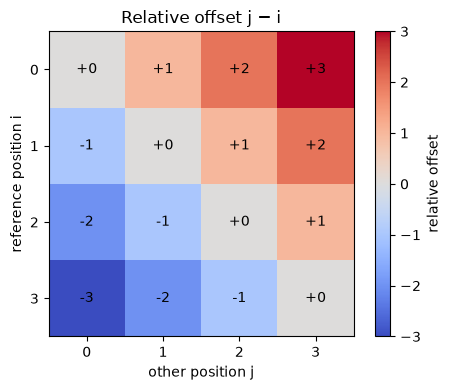

In [10]:
matrix_size = 4
positions_4 = np.arange(matrix_size)
relative_matrix = positions_4[None, :] - positions_4[:, None]  # j - i

print("Relative-position matrix (entry = j - i):")
print(relative_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(relative_matrix, cmap="coolwarm", vmin=-3, vmax=3)

for i in range(matrix_size):
    for j in range(matrix_size):
        ax.text(j, i, f"{relative_matrix[i, j]:+d}", ha="center", va="center", color="black")

ax.set_xticks(range(matrix_size), labels=range(matrix_size))
ax.set_yticks(range(matrix_size), labels=range(matrix_size))
ax.set_xlabel("other position j")
ax.set_ylabel("reference position i")
ax.set_title("Relative offset j − i")
fig.colorbar(image, ax=ax, label="relative offset")
plt.tight_layout()
plt.show()

<pre>Absolute: “Token is at position 7.”
Relative: “Token is 2 positions after me.”</pre>

## 9. Relative distance can survive an absolute shift

If both tokens move together, their absolute positions change while their relative separation can remain unchanged.

In [11]:
sequence_a_distance = 5 - 2
sequence_b_distance = 105 - 102

print("Sequence A: cat at 2,   mat at 5   → 5 - 2     =", sequence_a_distance)
print("Sequence B: cat at 102, mat at 105 → 105 - 102 =", sequence_b_distance)
print("Same relative distance?", sequence_a_distance == sequence_b_distance)

Sequence A: cat at 2,   mat at 5   → 5 - 2     = 3
Sequence B: cat at 102, mat at 105 → 105 - 102 = 3
Same relative distance? True


The absolute positions changed dramatically, but the relative distance stayed <code>+3</code>. This can make relative position information useful for patterns that appear in different places or sequence lengths. It is a useful design choice—not universally superior in every model.

## 10. Brief sinusoidal positional encoding demonstration

The original Transformer generated position values from sine and cosine functions instead of storing trainable position rows. We will implement only the small encoding calculation and visualize its patterns.

In [12]:
def make_sinusoidal_encoding(context_length, embedding_dim):
    encoding = torch.zeros(context_length, embedding_dim)
    position = torch.arange(context_length, dtype=torch.float32).unsqueeze(1)
    frequency_scale = torch.exp(
        torch.arange(0, embedding_dim, 2, dtype=torch.float32)
        * (-math.log(10000.0) / embedding_dim)
    )

    encoding[:, 0::2] = torch.sin(position * frequency_scale)
    encoding[:, 1::2] = torch.cos(position * frequency_scale)
    return encoding

sinusoidal = make_sinusoidal_encoding(context_length=10, embedding_dim=8)
print("Sinusoidal encoding shape:", tuple(sinusoidal.shape))
print("First three rows:\n", sinusoidal[:3])

Sinusoidal encoding shape: (10, 8)
First three rows:
 tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0998,  0.9950,  0.0100,  0.9999,  0.0010,  1.0000],
        [ 0.9093, -0.4161,  0.1987,  0.9801,  0.0200,  0.9998,  0.0020,  1.0000]])


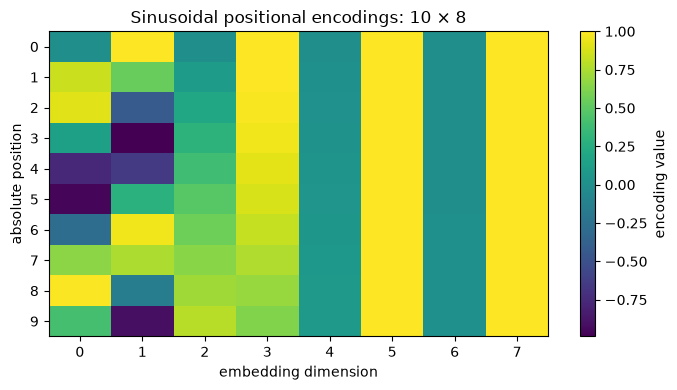

In [13]:
plt.figure(figsize=(7, 4))
plt.imshow(sinusoidal.numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label="encoding value")
plt.xlabel("embedding dimension")
plt.ylabel("absolute position")
plt.title("Sinusoidal positional encodings: 10 × 8")
plt.xticks(range(8))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

## 11. Learned vs. sinusoidal position information

| Learned absolute positional embedding | Sinusoidal positional encoding |
|---|---|
| Stored as trainable vectors | Generated mathematically |
| Often initialized randomly | Uses sine/cosine patterns |
| Changed by backpropagation | Has no learned embedding-table parameters |
| One row per supported absolute position | Original Transformer used this approach |

From here onward, we return to **learned absolute positional embeddings**.

## 12. Recreate the lecture's realistic dimensions

Now we scale the same idea up. We will print shapes only—not either large matrix.

In [14]:
torch.manual_seed(21)

vocab_size = 50_257
embedding_dim = 256
batch_size = 8
context_length = 4
stride = 4

token_embedding_layer = nn.Embedding(vocab_size, embedding_dim)
position_embedding_layer = nn.Embedding(context_length, embedding_dim)

print("Token embedding matrix shape:   ", tuple(token_embedding_layer.weight.shape))
print("  rows = vocabulary tokens")
print("  columns = embedding dimensions")
print("\nPosition embedding matrix shape:", tuple(position_embedding_layer.weight.shape))
print("  rows = possible positions")
print("  columns = embedding dimensions")

Token embedding matrix shape:    (50257, 256)
  rows = vocabulary tokens
  columns = embedding dimensions

Position embedding matrix shape: (4, 256)
  rows = possible positions
  columns = embedding dimensions


<pre>Token embedding matrix:      50,257 × 256
Position embedding matrix:        4 × 256</pre>

One table is indexed by **token ID**; the other is indexed by **position within the context window**.

## 13. A simple DataLoader-style batch

Here are eight windows, each containing four token IDs. The numbers are illustrative; no copyrighted text is needed.

In [15]:
inputs = torch.tensor([
    [101, 205, 309, 412],
    [205, 309, 412, 518],
    [309, 412, 518, 623],
    [412, 518, 623, 734],
    [518, 623, 734, 845],
    [623, 734, 845, 956],
    [734, 845, 956, 1067],
    [845, 956, 1067, 1178],
])

print(inputs)
print("\ninputs.shape:", tuple(inputs.shape))
print("8 = batch size")
print("4 = context length")

tensor([[ 101,  205,  309,  412],
        [ 205,  309,  412,  518],
        [ 309,  412,  518,  623],
        [ 412,  518,  623,  734],
        [ 518,  623,  734,  845],
        [ 623,  734,  845,  956],
        [ 734,  845,  956, 1067],
        [ 845,  956, 1067, 1178]])

inputs.shape: (8, 4)
8 = batch size
4 = context length


In [16]:
demo_tokens = "small windows move across this simple custom text slowly".split()

windows_stride_4 = [demo_tokens[i:i + 4] for i in range(0, len(demo_tokens) - 4 + 1, 4)]
windows_stride_1 = [demo_tokens[i:i + 4] for i in range(0, len(demo_tokens) - 4 + 1, 1)]

print("context_length = 4, stride = 4")
for window in windows_stride_4:
    print(window)

print("\ncontext_length = 4, stride = 1")
for window in windows_stride_1:
    print(window)

context_length = 4, stride = 4
['small', 'windows', 'move', 'across']
['this', 'simple', 'custom', 'text']

context_length = 4, stride = 1
['small', 'windows', 'move', 'across']
['windows', 'move', 'across', 'this']
['move', 'across', 'this', 'simple']
['across', 'this', 'simple', 'custom']
['this', 'simple', 'custom', 'text']
['simple', 'custom', 'text', 'slowly']


**Context length** is the window size. **Stride** is how far the window moves before producing the next sequence.

## 14. Convert <code>8 × 4</code> token IDs into <code>8 × 4 × 256</code>

The token embedding layer replaces every scalar ID with a 256-number vector.

In [17]:
token_embeddings = token_embedding_layer(inputs)

print("Input IDs shape:       ", tuple(inputs.shape))
print("Token embeddings shape:", tuple(token_embeddings.shape))
print("\n8 × 4 =", batch_size * context_length, "token occurrences")
print("Every occurrence now has", embedding_dim, "numbers.")

Input IDs shape:        (8, 4)
Token embeddings shape: (8, 4, 256)

8 × 4 = 32 token occurrences
Every occurrence now has 256 numbers.


<pre>8 × 4 × 256
│   │    │
│   │    └── numbers representing each token
│   └─────── tokens in each sequence
└─────────── sequences in the batch</pre>

## 15. Generate positional embeddings with <code>torch.arange</code>

All sequences have the same four within-window positions, so the position IDs are simply <code>[0, 1, 2, 3]</code>.

In [18]:
positions = torch.arange(context_length)
pos_embeddings = position_embedding_layer(positions)

print("Position IDs:", positions.tolist())
print("Position embeddings shape:", tuple(pos_embeddings.shape))
print("These four rows are P0, P1, P2, and P3.")

Position IDs: [0, 1, 2, 3]
Position embeddings shape: (4, 256)
These four rows are P0, P1, P2, and P3.


## 16. Why all eight sequences reuse the same four vectors

<pre>Sequence 1: token0 + P0   token1 + P1   token2 + P2   token3 + P3
Sequence 2: token0 + P0   token1 + P1   token2 + P2   token3 + P3
    ⋮
Sequence 8: token0 + P0   token1 + P1   token2 + P2   token3 + P3</pre>

Position 0 means position 0 regardless of which sequence in the batch is being processed. Therefore the model stores <code>4 × 256</code> position values—not eight separate copies with shape <code>8 × 4 × 256</code>.

## Broadcasting in one idea

Broadcasting lets PyTorch apply the same `[T, D]` position matrix to every sequence in a `[B, T, D]` batch. It behaves as if the matrix were copied `B` times, without requiring us to create those copies manually.

## 17. Broadcasting: reuse without manual copies

First we make the dimensions tiny enough to inspect every number:

<pre>token embeddings:       2 × 3 × 2
positional embeddings:      3 × 2</pre>

In [19]:
tiny_token_embeddings = torch.tensor([
    [[1., 10.], [2., 20.], [3., 30.]],
    [[4., 40.], [5., 50.], [6., 60.]],
])

tiny_positional_embeddings = torch.tensor([
    [0.1, 0.2],  # P0
    [1.0, 2.0],  # P1
    [10., 20.],  # P2
])

tiny_final_embeddings = tiny_token_embeddings + tiny_positional_embeddings

print("Token embeddings (2 × 3 × 2):\n", tiny_token_embeddings)
print("\nPosition embeddings (3 × 2):\n", tiny_positional_embeddings)
print("\nResult after broadcasting:\n", tiny_final_embeddings)

Token embeddings (2 × 3 × 2):
 tensor([[[ 1., 10.],
         [ 2., 20.],
         [ 3., 30.]],

        [[ 4., 40.],
         [ 5., 50.],
         [ 6., 60.]]])

Position embeddings (3 × 2):
 tensor([[ 0.1000,  0.2000],
        [ 1.0000,  2.0000],
        [10.0000, 20.0000]])

Result after broadcasting:
 tensor([[[ 1.1000, 10.2000],
         [ 3.0000, 22.0000],
         [13.0000, 50.0000]],

        [[ 4.1000, 40.2000],
         [ 6.0000, 52.0000],
         [16.0000, 80.0000]]])


In [20]:
for batch_index in range(2):
    print(f"Sequence {batch_index + 1} checks:")
    for position in range(3):
        expected = tiny_token_embeddings[batch_index, position] + tiny_positional_embeddings[position]
        actual = tiny_final_embeddings[batch_index, position]
        print(f"  position {position} used P{position}:", torch.equal(expected, actual))

Sequence 1 checks:
  position 0 used P0: True
  position 1 used P1: True
  position 2 used P2: True
Sequence 2 checks:
  position 0 used P0: True
  position 1 used P1: True
  position 2 used P2: True


<pre>2 × 3 × 2
+   3 × 2
─────────
2 × 3 × 2</pre>

PyTorch aligns the trailing dimensions and reuses the <code>3 × 2</code> position matrix across the batch. We do not need to manually create copies.

## 18. Perform the realistic addition

The exact same broadcasting rule works for the realistic tensors.

In [21]:
input_embeddings = token_embeddings + pos_embeddings

print("token_embeddings: ", tuple(token_embeddings.shape))
print("pos_embeddings:   ", tuple(pos_embeddings.shape))
print("input_embeddings: ", tuple(input_embeddings.shape))

token_embeddings:  (8, 4, 256)
pos_embeddings:    (4, 256)
input_embeddings:  (8, 4, 256)


<pre>Token embedding
       +
Position embedding
       =
Final input embedding</pre>

The result remains <code>8 × 4 × 256</code>. This is the representation that would next be passed into a Transformer.

## 19. One token before and after adding position

We inspect only the first eight dimensions of the first token occurrence so the output stays readable.

In [22]:
batch_index = 0
position_index = 0

token_vector = token_embeddings[batch_index, position_index]
position_vector = pos_embeddings[position_index]
final_vector = input_embeddings[batch_index, position_index]

print("Token vector, first 8 values:   ", token_vector[:8])
print("Position vector, first 8 values:", position_vector[:8])
print("Final vector, first 8 values:   ", final_vector[:8])
print("\nDoes token + position equal final?", torch.allclose(token_vector + position_vector, final_vector))

Token vector, first 8 values:    tensor([ 0.0556,  1.2707,  0.9254,  0.8614, -0.0217,  0.7598, -1.8096,  0.3662],
       grad_fn=<SliceBackward0>)
Position vector, first 8 values: tensor([ 0.0676,  0.0496,  1.2229,  0.9056, -1.2335, -0.7728,  1.3146, -0.3209],
       grad_fn=<SliceBackward0>)
Final vector, first 8 values:    tensor([ 0.1233,  1.3203,  2.1484,  1.7670, -1.2552, -0.0130, -0.4950,  0.0453],
       grad_fn=<SliceBackward0>)

Does token + position equal final? True


## 20. The same token ID at positions 0 and 3

Token ID <code>100</code> selects one fixed token row both times. The differing position rows create different final inputs.

In [23]:
repeated_ids = torch.tensor([100, 100])
repeated_token_vectors = token_embedding_layer(repeated_ids)

same_token_at_0 = repeated_token_vectors[0] + pos_embeddings[0]
same_token_at_3 = repeated_token_vectors[1] + pos_embeddings[3]

print("Token embedding identical?", torch.equal(repeated_token_vectors[0], repeated_token_vectors[1]))
print("P0 equals P3?", torch.equal(pos_embeddings[0], pos_embeddings[3]))
print("Final input vectors equal?", torch.equal(same_token_at_0, same_token_at_3))
print("Euclidean distance between final vectors:", torch.linalg.vector_norm(same_token_at_0 - same_token_at_3).item())
print("\nFirst 8 values at position 0:", same_token_at_0[:8])
print("First 8 values at position 3:", same_token_at_3[:8])

Token embedding identical? True
P0 equals P3? False
Final input vectors equal? False
Euclidean distance between final vectors: 22.650392532348633

First 8 values at position 0: tensor([ 1.1887,  0.9129,  0.3782,  0.8803, -1.7377, -0.9802,  1.3029,  0.0852],
       grad_fn=<SliceBackward0>)
First 8 values at position 3: tensor([ 0.4706,  1.9221, -2.0727,  0.0129, -1.4887,  0.4688,  0.0551,  1.2569],
       grad_fn=<SliceBackward0>)


## How position rows learn

Positional embeddings are model parameters. Next-token loss flows backward through the addition, so the position rows used in the batch receive gradients and can be updated.

## 21. Positional embeddings are trainable parameters

We now prove that token and learned position rows both receive gradients from the **same next-token prediction loss**.

<pre>token IDs
    ↓
token embedding
    + position embedding
    ↓
simple Linear layer
    ↓
next-token logits → loss</pre>

There is no Transformer in this toy model.

In [24]:
torch.manual_seed(30)

toy_vocab_size = 6
toy_embedding_dim = 4
toy_context_length = 4

toy_token_embedding = nn.Embedding(toy_vocab_size, toy_embedding_dim)
toy_position_embedding = nn.Embedding(toy_context_length, toy_embedding_dim)
toy_output_layer = nn.Linear(toy_embedding_dim, toy_vocab_size)

toy_inputs = torch.tensor([[0, 1, 2, 3]])
toy_targets = torch.tensor([[1, 2, 3, 4]])
toy_positions = torch.arange(toy_context_length)

selected_token_id = 0
selected_position = 0
token_before = toy_token_embedding.weight[selected_token_id].detach().clone()
position_before = toy_position_embedding.weight[selected_position].detach().clone()

optimizer = torch.optim.SGD(
    list(toy_token_embedding.parameters())
    + list(toy_position_embedding.parameters())
    + list(toy_output_layer.parameters()),
    lr=0.1,
)

print("Token row before:   ", token_before)
print("Position row before:", position_before)

Token row before:    tensor([-1.9309,  0.9058, -0.0324, -1.4994])
Position row before: tensor([ 0.3070, -1.3013, -0.2645, -0.8094])


In [25]:
optimizer.zero_grad()

toy_token_vectors = toy_token_embedding(toy_inputs)
toy_position_vectors = toy_position_embedding(toy_positions)
toy_input_vectors = toy_token_vectors + toy_position_vectors
toy_logits = toy_output_layer(toy_input_vectors)

loss = F.cross_entropy(
    toy_logits.reshape(-1, toy_vocab_size),
    toy_targets.reshape(-1),
)
loss.backward()

token_gradient = toy_token_embedding.weight.grad[selected_token_id].detach().clone()
position_gradient = toy_position_embedding.weight.grad[selected_position].detach().clone()

print("Loss:", loss.item())
print("Selected token-row gradient:   ", token_gradient)
print("Selected position-row gradient:", position_gradient)
print("Token gradient is nonzero?", bool(torch.any(token_gradient != 0)))
print("Position gradient is nonzero?", bool(torch.any(position_gradient != 0)))

optimizer.step()

Loss: 1.8308316469192505
Selected token-row gradient:    tensor([ 0.0377,  0.0512, -0.0588, -0.0529])
Selected position-row gradient: tensor([ 0.0377,  0.0512, -0.0588, -0.0529])
Token gradient is nonzero? True
Position gradient is nonzero? True


In [26]:
token_after = toy_token_embedding.weight[selected_token_id].detach().clone()
position_after = toy_position_embedding.weight[selected_position].detach().clone()

print("Token embedding before:", token_before)
print("Token embedding after: ", token_after)
print("Token row changed?", not torch.equal(token_before, token_after))

print("\nPosition embedding before:", position_before)
print("Position embedding after: ", position_after)
print("Position row changed?", not torch.equal(position_before, position_after))

Token embedding before: tensor([-1.9309,  0.9058, -0.0324, -1.4994])
Token embedding after:  tensor([-1.9346,  0.9007, -0.0265, -1.4941])
Token row changed? True

Position embedding before: tensor([ 0.3070, -1.3013, -0.2645, -0.8094])
Position embedding after:  tensor([ 0.3032, -1.3064, -0.2586, -0.8041])
Position row changed? True


There is no separate objective for positional embeddings. The next-token prediction loss backpropagates into:

- token embedding weights
- positional embedding weights
- output-layer weights
- and, in a complete language model, the other model weights

## 22. What is—and is not—stored

Two separate tables are stored:

| Vocabulary/token embedding table | Positional embedding table |
|---|---|
| token ID → token vector | position → position vector |
| <code>cat → C</code> | <code>position 0 → P0</code> |
| <code>dog → D</code> | <code>position 1 → P1</code> |
| one row per vocabulary token | one row per supported position |

The vocabulary does **not** store a separate position vector for every word.

<pre>cat at position 2 → C + P2
dog at position 2 → D + P2</pre>

The same <code>P2</code> is reused.

## 23. What a positional embedding does not mean

<code>P2</code> does **not** mean:

> “how the word cat behaves when it is at position 2.”

<code>P2</code> means approximately:

> “a learned representation associated with position 2.”

Later processing combines:

<pre>token identity
+ position
+ Transformer attention and surrounding context</pre>

The position vector alone does not understand a token or determine its behavior.

## 24. Token vs. position vs. contextual representation

<pre>Token embedding:
“What token am I?”

Position embedding:
“Where am I?”

Token + position:
initial input representation

Transformer/self-attention:
“Given what I am, where I am,
and the surrounding context,
how should I represent this occurrence?”</pre>

Compare:

- “I deposited money in the **bank**.”
- “We sat beside the river **bank**.”

<code>bank</code> begins with the same token embedding. It also receives position information. Later, a Transformer can use the different surrounding words to create different **contextual representations**. We do not need to implement that Transformer to understand the distinction.

## 25. Final visual pipeline

<pre>Raw text
   ↓
Tokenizer
   ↓
Token IDs
   ↓
┌───────────────────────────────┐
│ Token embedding lookup        │
│ token ID → token vector       │
└───────────────────────────────┘
               +
┌───────────────────────────────┐
│ Positional embedding lookup   │
│ position → position vector    │
└───────────────────────────────┘
               ↓
       Final input embeddings
               ↓
         8 × 4 × 256
               ↓
           Transformer
               ↓
      Next-token prediction
               ↓
              Loss
               ↓
        Backpropagation
               ↓
Updates:
• token embeddings
• positional embeddings
• Transformer weights</pre>

## 26. Final recap quiz

Try answering without running more code or opening the answers.

1. Why cannot token embeddings alone identify a token's position?
2. Why must token and positional embedding dimensions match when using addition?
3. What is the difference between absolute and relative position?
4. In relative positioning, is there one permanent reference token for the whole sentence?
5. Why is the token embedding matrix shaped <code>vocab_size × embedding_dim</code>?
6. Why is the positional embedding matrix shaped <code>context_length × embedding_dim</code>?
7. Why does <code>8 × 4 × 256 + 4 × 256</code> work in PyTorch?
8. Are token embeddings and learned positional embeddings both updated by next-token training loss?

<details>
<summary><strong>Answers — check only after attempting</strong></summary>

1. An embedding lookup depends on token ID, so the same ID always selects the same row regardless of where it appears.
2. Addition is element-wise; every token-vector component needs a matching position-vector component.
3. Absolute position identifies an exact location; relative position describes one location compared with a chosen reference location.
4. No. When comparing positions <code>i</code> and <code>j</code>, <code>i</code> can act as the reference and the offset can be <code>j − i</code>.
5. There is one row per vocabulary token and <code>embedding_dim</code> values in each row.
6. There is one row per supported position in the context window and <code>embedding_dim</code> values in each row.
7. Broadcasting reuses the <code>4 × 256</code> position matrix across all eight sequences.
8. Yes. The same loss backpropagates gradients into both trainable tables, as well as later model parameters.

</details>

## Takeaway

<pre>Token embedding = what
Position embedding = where
Token + position = initial model input
Attention/context = how this occurrence should be represented</pre>

You are now ready to study how these final input embeddings enter self-attention.

### Checkpoint

Token embeddings answer “which token?” and positional embeddings add “where?”. Their matching dimension `D` allows addition, and broadcasting reuses the same positions across a batch.

**Next:** Notebook 5 connects the complete pipeline.